<h1>Train — EfficientNet-B0</h1>

Trains and evaluates EfficientNet-B0 using the tuned hyperparameters from `ARCH_HYPERPARAMS["efficientnet_b0"]`, then saves its results and weights to disk for the results notebook.

In [1]:
from wwtw_utils import *

Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190


## Build dataloaders + class weights for this architecture

In [2]:
cfg = ARCH_HYPERPARAMS["efficientnet_b0"]

# The tuned batch size (cfg["batch_size"]) can be too large to fit in GPU
# memory for a deeper model like this one, even though it fit fine for
# whichever model the tuning trials actually ran on. Rather than hard-coding
# a smaller batch size (and drifting from the tuned hyperparameters), cap the
# *actual* loader batch size at MICRO_BATCH_CAP and use gradient accumulation
# in train_model to still reach the tuned effective batch size.
micro_batch = min(cfg["batch_size"], MICRO_BATCH_CAP)
accum_steps = max(1, round(cfg["batch_size"] / micro_batch))
print(f"EfficientNet-B0: micro batch = {micro_batch}, accumulation steps = {accum_steps} "
      f"(effective batch size ≈ {micro_batch * accum_steps}, tuned value = {cfg['batch_size']})")

# This backbone gets its own dataloaders — its own (capped) batch size, and
# (for InceptionNet v3) its own image size.
train_ds_arch, val_ds_arch, test_ds_arch, train_loader_arch, val_loader_arch, test_loader_arch = \
    get_dataloaders(cfg["img_size"], micro_batch)

class_weights_arch = make_class_weights(train_ds_arch)

EfficientNet-B0: micro batch = 16, accumulation steps = 6 (effective batch size ≈ 96, tuned value = 96)


## Define the model

In [3]:
# ---------------------------------------------------------
# Define the CNN (Transfer Learning with EfficientNet-B0)
# ---------------------------------------------------------
model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)

# EfficientNet's classifier is nn.Sequential(Dropout, Linear) — swap out
# just the Linear layer for our (optionally deeper) classifier head, same
# as the fc/classifier swaps used for the other architectures.
in_f = model.classifier[1].in_features
model.classifier[1] = build_classifier_head(in_f, cfg["hidden_layers"], cfg["neurons"], num_classes)

model = model.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_arch)
optimizer = optim.Adam(
    model.parameters(),
    lr=cfg["lr"],
    betas=(cfg["beta1"], ADAM_BETA2),
    weight_decay=WEIGHT_DECAY,
)
# Step-based decay: LR x0.1 every Es epochs.
scheduler = StepLR(optimizer, step_size=cfg["step_size"], gamma=0.1)

## Train, then plot training curves

[EfficientNet-B0] Using gradient accumulation: 6 micro-batches per optimizer step (effective batch size ≈ micro_batch x 6).


Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190
Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190
Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190
Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190


Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190
Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190
Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190
Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190
[EfficientNet-B0] Epoch   1/100 | LR: 1.38e-03 | train loss 1.0074 acc 0.544 | val loss 1.1824 acc 0.431 *


Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190
Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190
Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190
Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190


Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190
Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190
Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190
Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190
[EfficientNet-B0] Epoch   2/100 | LR: 1.38e-03 | train loss 0.8297 acc 0.658 | val loss 0.6115 acc 0.765 *


...

Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190
Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190
Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190
Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190
[EfficientNet-B0] Epoch  29/100 | LR: 1.38e-04 | train loss 0.1659 acc 0.933 | val loss 0.4418 acc 0.850


Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190
Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190
Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190
Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190


Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190
Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190
Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190
Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190
[EfficientNet-B0] Epoch  30/100 | LR: 1.38e-04 | train loss 0.1412 acc 0.954 | val loss 0.4239 acc 0.856


Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190
Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190
Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190
Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190


Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190
Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190
Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190
Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190
[EfficientNet-B0] Epoch  31/100 | LR: 1.38e-04 | train loss 0.1195 acc 0.965 | val loss 0.4479 acc 0.856

[EfficientNet-B0] No val loss improvement for 10 epochs — stopping early at epoch 31.

[EfficientN

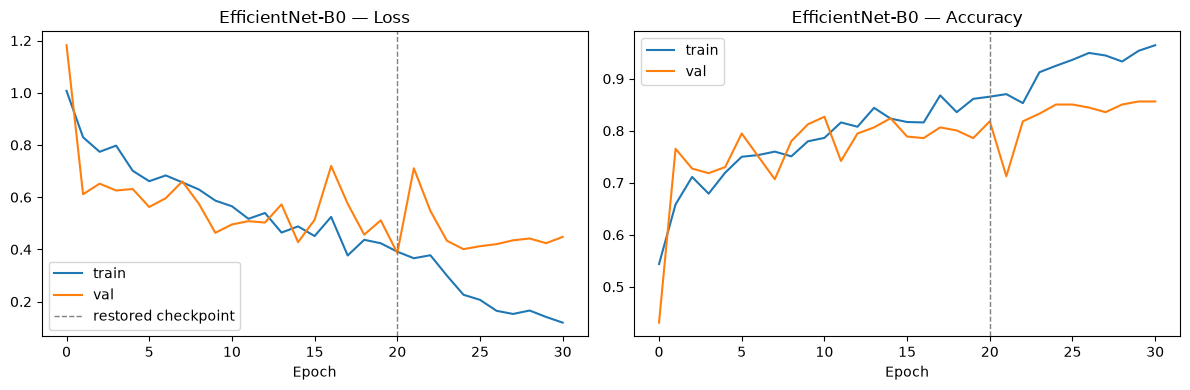

In [4]:
history = train_model(
    model, train_loader_arch, val_loader_arch, optimizer, scheduler,
    criterion, EPOCHS, EARLY_STOP_PATIENCE, "EfficientNet-B0", is_inception=False,
    accum_steps=accum_steps,
)
plot_training_curves(history, "EfficientNet-B0")

## Evaluate on the test set

Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190
Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190
Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190
Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1212 | Val: 341 | Test: 190
[EfficientNet-B0] Test accuracy: 0.795


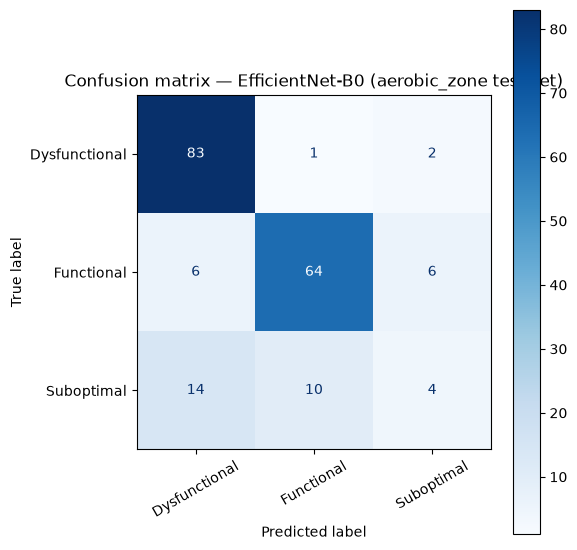

               precision    recall  f1-score   support

Dysfunctional      0.806     0.965     0.878        86
   Functional      0.853     0.842     0.848        76
   Suboptimal      0.333     0.143     0.200        28

     accuracy                          0.795       190
    macro avg      0.664     0.650     0.642       190
 weighted avg      0.755     0.795     0.766       190



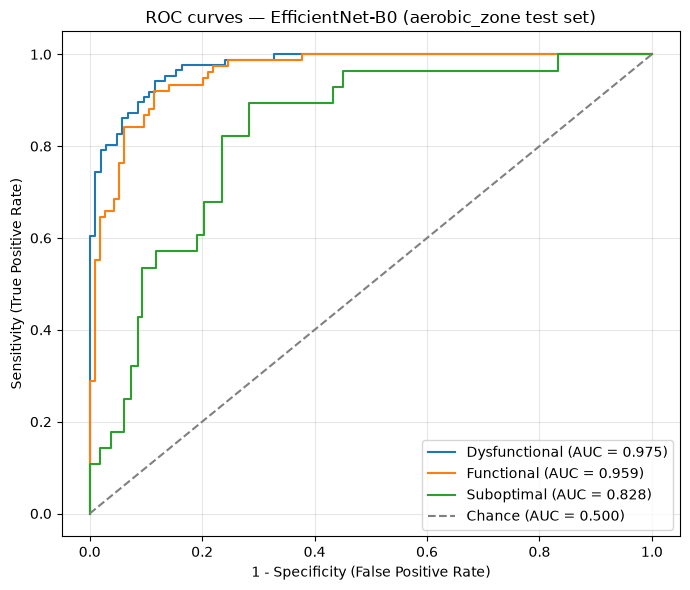

AUC (area under ROC curve) per class:
  Dysfunctional  : 0.975
  Functional     : 0.959
  Suboptimal     : 0.828

Mean AUC (over 3/3 classes with test examples): 0.921


(np.float64(0.7947368421052632),
 {'Dysfunctional': 0.9746198568872988,
  'Functional': 0.9587950138504155,
  'Suboptimal': 0.8284832451499118})

In [5]:
evaluate_and_record(
    model, test_loader_arch, "EfficientNet-B0", history,
    img_size=cfg["img_size"], hidden_layers=cfg["hidden_layers"], neurons=cfg["neurons"],
)

## Save results + model weights to disk

In [6]:
save_result("EfficientNet-B0", "efficientnet_b0")

Saved results to ../results/aerobic_zone_pad_aug/results_aerobic_zone_efficientnet_b0_stratified.pkl


Saved model weights to ../models/pad/aerobic_zone_efficientnet_b0_cnn.pt
